# Fitting PTT model to HA Rheological Data

BIEN 514 Final Project

Winter 2026

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit, fsolve, brentq
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
# load SAOS data
saos640 = pd.read_excel("SAOS.xlsx", sheet_name='640 kDa')
saos1060 = pd.read_excel("SAOS.xlsx", sheet_name='1060 kDa')
saos2010 = pd.read_excel("SAOS.xlsx", sheet_name='2010 kDa')

# adding angualr frequency
saos640['Angular Frequency'] = saos640['Frequency']*2*np.pi
saos1060['Angular Frequency'] = saos1060['Frequency']*2*np.pi
saos2010['Angular Frequency'] = saos2010['Frequency']*2*np.pi

# load steady-shear data
steady640 = pd.read_excel("SteadyShear.xlsx", sheet_name='640 kDa')
steady1060 = pd.read_excel("SteadyShear.xlsx", sheet_name='1060 kDa')
steady2010 = pd.read_excel("SteadyShear.xlsx", sheet_name='2010 kDa')

# zero shear viscosity
zero640 = steady640['Viscosity'][0]
zero1060 = steady1060['Viscosity'][0]
zero2010 = steady2010['Viscosity'][0]

## Fitting SAOS

In [3]:
def moduli(omega, G, rt):
    """
    calculate the shear storage and loss moduli for SAOS
    
    Parameters
    ----------
        omega: shear frequency data
        G: shear modulus
        rt: relaxation time
    """

    denom = 1 + ((omega * rt)**2)
    G_storage = (G * ((omega * rt)**2)) / denom
    G_loss = (G * omega * rt) / denom

    return G_storage, G_loss

In [4]:
def multimode(omega, params):
    """
    calculate the storage and loss moduli for n modes
    
    Parameters
    ----------
        omega: shear frequency data
        *params: G and rt for each mode [G_i, rt_i ... G_n, rt_n]
    """

    G_params = params[::2]
    rt_params = params[1::2]

    storage_total = np.zeros_like(omega)
    loss_total = np.zeros_like(omega)

    for G, rt in zip(G_params, rt_params):
        G_storage, G_loss = moduli(omega, G, rt)
        storage_total += G_storage
        loss_total += G_loss
    
    return storage_total, loss_total


In [5]:
def residuals(params, data):

    omega = data['Angular Frequency']
    s_exp = data['Storage']
    l_exp = data['Loss']

    s_model, l_model = multimode(omega, params)

    s_resid = (s_exp - s_model) / s_exp
    l_resid = (l_exp - l_model) / l_exp

    all_resid = np.concatenate((s_resid, l_resid))
    ssr = np.sum(all_resid**2)
    return ssr

In [6]:
def visc_constraint(params, eta0):
    return np.sum(params[::2]*params[1::2]) - eta0


In [7]:
def saos_fit(data, eta_0, p0=[10, 1, 100, 0.1]):

    my_bounds = [(0, None)]*len(p0)

    cons = {'type': 'eq', 'fun': visc_constraint, 'args': (eta_0,)}

    res = minimize(
        residuals,
        p0,
        args=(data,),
        bounds=my_bounds,
        constraints=cons,
        method='SLSQP'
    )

    data['Storage Fit'], data['Loss Fit'] = multimode(data['Angular Frequency'], res.x)

    return res.x

In [8]:
def plot_saos(ax, data, weight:str, color:str):
    x = data['Angular Frequency']

    ax.scatter(x, data['Storage'], color=color, label=rf"{weight} $G$'")
    ax.scatter(x, data['Loss'], marker='o', facecolors='none', color=color, label=rf"{weight} $G''$")

    ax.plot(x, data['Storage Fit'], color=color, label=r"Model $G'$")
    ax.plot(x, data['Loss Fit'], '--', color=color, label=r"Model $G''$")

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(r'Oscillation Frequency, $\omega$ (rad/s)', size=12)
    ax.set_ylabel(r"Viscoelastic Moduli, $G',  G''$ (Pa)", size=12)

    ax.legend(ncols=2, loc='lower right')

In [9]:
p640 = [
    0.05, 1,
    100, 0.01,
]

p1060 = [
    10, 0.5,
    100, 0.05,
]

p2010 = [
    100, 1,
    250, 0.05,
]

fit640 = saos_fit(saos640, zero640, p0=p640)
fit1060 = saos_fit(saos1060, zero1060, p0=p1060)
fit2010 = saos_fit(saos2010, zero2010, p0=p2010)

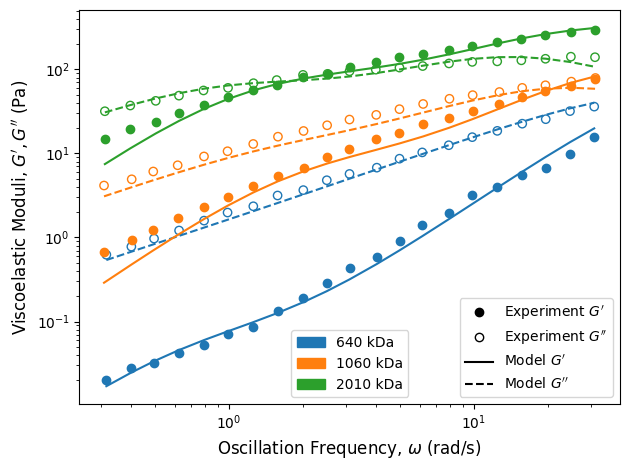

In [10]:
fig, ax = plt.subplots(1, 1)

plot_saos(ax, saos640, '640 kDa', 'tab:blue')
plot_saos(ax, saos1060, '1060 kDa', 'tab:orange')
plot_saos(ax, saos2010, '2010 kDa', 'tab:green')

mw_handles = [Patch(color='tab:blue', label='640 kDa'),
            Patch(color='tab:orange', label='1060 kDa'),
            Patch(color='tab:green', label='2010 kDa')]

mw_legend = ax.legend(handles=mw_handles, loc='lower center')
ax.add_artist(mw_legend)

mod_handles = [
    Line2D([0], [0], color='black', marker='o', ls=''),
    Line2D([0], [0], color='black', marker='o', mfc='w', ls=''),
    Line2D([0], [0], color='black', ls='-'),
    Line2D([0], [0], color='black', ls='--')
]

mod_labels = [r"Experiment $G'$",
              r"Experiment $G''$",
              r"Model $G'$",
              r"Model $G''$"]

ax.legend(handles=mod_handles, labels=mod_labels, loc='lower right')


fig.tight_layout()
fig.savefig('saos.svg')

## Fitting Steady Shear

In [11]:
def viscosity(gamma_dot, saosfit, params):
    """
    Cumulative viscosity function for linear PTT model

    Parameters
    ----------
        gamma_dot : shear rate
        saosfit: parameters from SAOS fit
        params : list of epsilon [epsilon_i ... epsilon_n]
    
    """
    rt_mode = saosfit[1::2]
    eta0_mode = saosfit[::2] * rt_mode

    eta = np.zeros_like(gamma_dot)

    for rt_i, eta0_i, epsilon_i in zip(rt_mode, eta0_mode, params):

        denom = (1 + (2*epsilon_i * ((rt_i * gamma_dot)**2))) ** (1/3)
        eta += eta0_i / denom

    return eta

In [12]:
def steady_fit(data, saosfit):
    fit_func = lambda gamma_dot, *params: viscosity(gamma_dot, saosfit, params)

    initial = [1, 1]

    popt, _ = curve_fit(fit_func, 
                        data['Shear rate'], 
                        data['Viscosity'], 
                        p0=initial,
                        bounds=(0, 1),
                        sigma=data['Viscosity'],
                        method='trf')
    
    data['Fit'] = viscosity(data['Shear rate'], saosfit, popt)

    return popt

In [13]:
def plot_steady(data, ax, weight:str):
    ax.scatter(data['Shear rate'], data['Viscosity'], label=rf'{weight}')
    ax.plot(data['Shear rate'], data['Fit'], label=r'$\eta(\dot{\gamma})$')

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(r'Shear Rate, $\dot{\gamma}$ $(s^{-1})$', size=12)
    ax.set_ylabel(r'Apparent Viscosity, $\eta$ $(Pa \cdot s)$', size=12)

In [14]:
steadyfit640 = steady_fit(steady640, fit640)
steadyfit1060 = steady_fit(steady1060, fit1060)
steadyfit2010 = steady_fit(steady2010, fit2010)

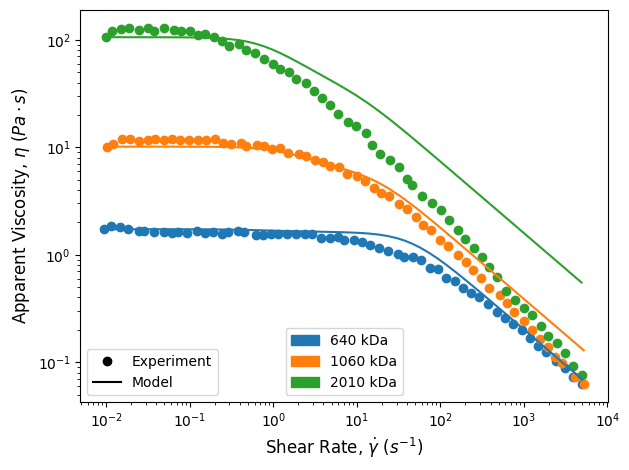

In [15]:
fig, ax = plt.subplots(1, 1)

plot_steady(steady640, ax, '640 kDa')
plot_steady(steady1060, ax, '1060 kDa')
plot_steady(steady2010, ax, '2010 kDa')

mw_handles = [Patch(color='tab:blue', label='640 kDa'),
            Patch(color='tab:orange', label='1060 kDa'),
            Patch(color='tab:green', label='2010 kDa')]

mw_legend = ax.legend(handles=mw_handles, loc='lower center')
ax.add_artist(mw_legend)

mod_handles = [
    Line2D([0], [0], color='black', marker='o', ls=''),
    Line2D([0], [0], color='black', ls='-'),
]

mod_labels = [r"Experiment",
              r"Model"]

ax.legend(handles=mod_handles, labels=mod_labels, loc='lower left')

fig.tight_layout()
fig.savefig('steady.svg')

## Exponential PTT

In [89]:
def eta_scalar(g_dot, eta_0, shear_G, epsilon):
    """
    implicitly calculate viscosity based on PTT model

    Parameters
    ----------
        g_dot: shear rate
        eta_0: zero shear viscosity
        shear_G: shear modulus
        epsilon: extensibility parameter
    """

    def objective(eta):
        return np.log(eta_0/eta) - (2 * epsilon * ((eta*g_dot/shear_G)**2))

    return brentq(objective, a=1e-6, b=eta_0)
                    
# vectorizing eta implicit solver
eta_vector = np.vectorize(eta_scalar, otypes=[float])


In [90]:
def eta_total(g_dot, saosfit, params):

    modes_G = saosfit[::2]
    modes_eta0 = modes_G * saosfit[1::2]

    # total_viscosity = np.zeros_like(g_dot)
    eta_results = []

    for eta_0, shear_G, epsilon in zip(modes_eta0, modes_G, params):

        # total_viscosity += eta_vector(g_dot, eta_0, shear_G, epsilon)
        eta_results.append(eta_vector(g_dot, eta_0, shear_G, epsilon))
    
    return eta_results # total_viscosity

In [91]:
p0 = [0.1, 0.1]
saosfit = fit640
data = steady640

fit_func = lambda gamma_dot, *epsilon: np.add(*eta_total(gamma_dot, saosfit, epsilon)) # type: ignore

popt, _ = curve_fit(fit_func, 
                    data['Shear rate'], 
                    data['Viscosity'], 
                    bounds=[0, np.inf],
                    p0=p0,
                    sigma=data['Viscosity'])

In [92]:
test = eta_total(data['Shear rate'], saosfit, popt)

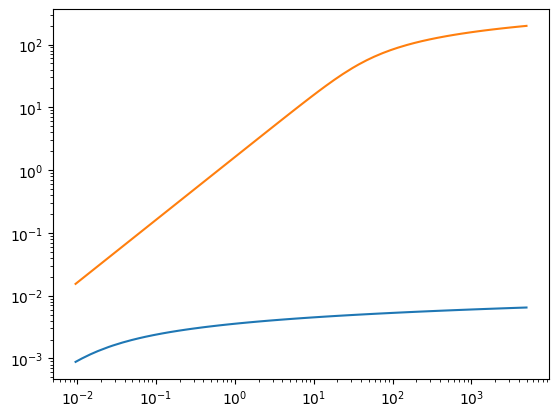

In [93]:
plt.loglog(data['Shear rate'], test[0]*data['Shear rate'])
plt.loglog(data['Shear rate'], test[1]*data['Shear rate'])

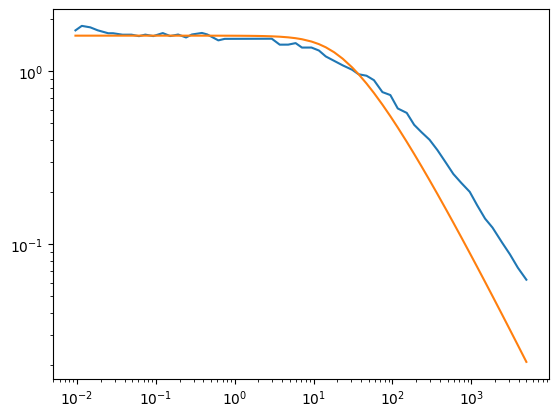

In [123]:
plt.loglog(data['Shear rate'], data['Viscosity'])
# plt.loglog(data['Shear rate'], np.add(*test))


test2 = eta_vector(data['Shear rate'], 1.61, 10, 0.02)
plt.loglog(data['Shear rate'], test2)
